Step 2: Load and Preprocess the Dataset

In [4]:
import pandas as pd
import os

# Define the dataset path using your absolute file path
dataset_path = "./spotify_top_1000_tracks.csv"

# Load dataset
df = pd.read_csv(dataset_path, encoding="utf-8")


# Convert release_date and extract year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# FIX: We REMOVE the line that tried to create 'duration_min'
# because it already exists in the CSV file you loaded.
# (The 'duration_min' column is ready for use!)
print(" Dataset loaded and basic preprocessing complete!")
print(df.head(5))

 Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   
3                Heat Waves   Glass Animals   
4           Let Me Love You        DJ Snake   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   
3                                          Dreamland   2020-08-07          87   
4                                             Encore   2016-08-05          87   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spot

Step 3

In [5]:
import numpy as np

# Clean up text columns
df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()

# Convert 'year' to integer
df['year'] = df['year'].fillna(0).astype(int)

# Drop unnecessary columns
cols_to_drop = ['spotify_url', 'id', 'release_date']

# Check for and add other common audio feature columns if they exist
if 'time_signature' in df.columns:
    cols_to_drop.append('time_signature')
if 'key' in df.columns:
    cols_to_drop.append('key')
if 'mode' in df.columns:
    cols_to_drop.append('mode')

df = df.drop(columns=cols_to_drop, errors='ignore')

# Feature Engineering: Tempo Category
tempo_bins = [0, 100, 140, np.inf]
tempo_labels = ['Slow', 'Medium', 'Fast']

if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut( # Create tempo category column
        df['tempo'], bins=tempo_bins,
    labels=tempo_labels, right=False)
    print("Feature 'tempo_category' created.")
else:
    print("Warning: 'tempo' column not found; skipping 'tempo_category' creation.")

# Remove duplicates
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print(f" Data cleaning and feature engineering complete.")
print(f"Final Row Count after deduplication: {len(df)}")

 Data cleaning and feature engineering complete.
Final Row Count after deduplication: 971


1. Histogram

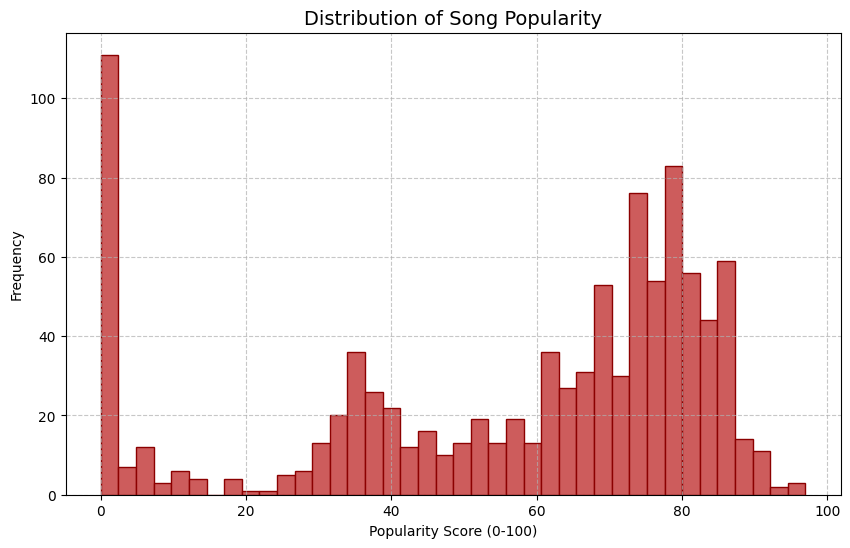

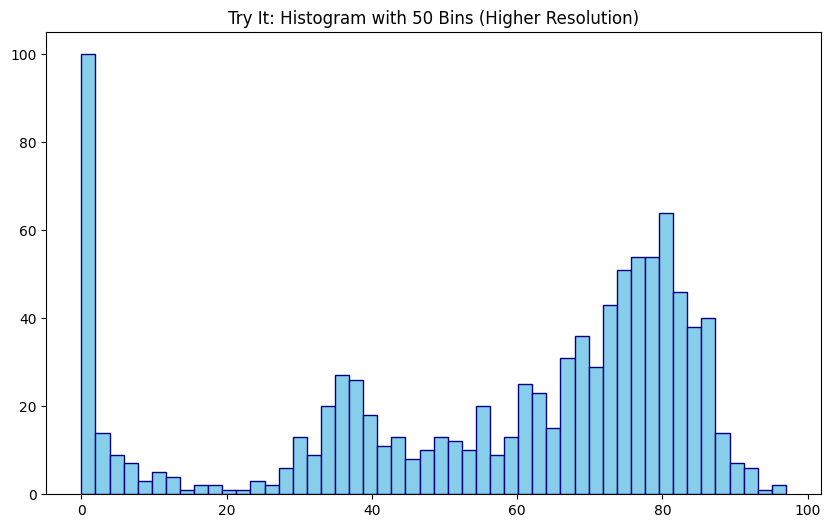

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))


plt.hist(df['popularity'], bins=40, color='indianred', edgecolor='darkred')


plt.title('Distribution of Song Popularity', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency')


plt.grid(True, linestyle='--', alpha=0.7)


plt.show()

# Try It:
plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=50, color='skyblue', edgecolor='navy')
plt.title('Try It: Histogram with 50 Bins (Higher Resolution)')
plt.show()


2. Boxplot

C:\Users\daphn\AppData\Local\Temp\ipykernel_9808\3208766454.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='viridis')


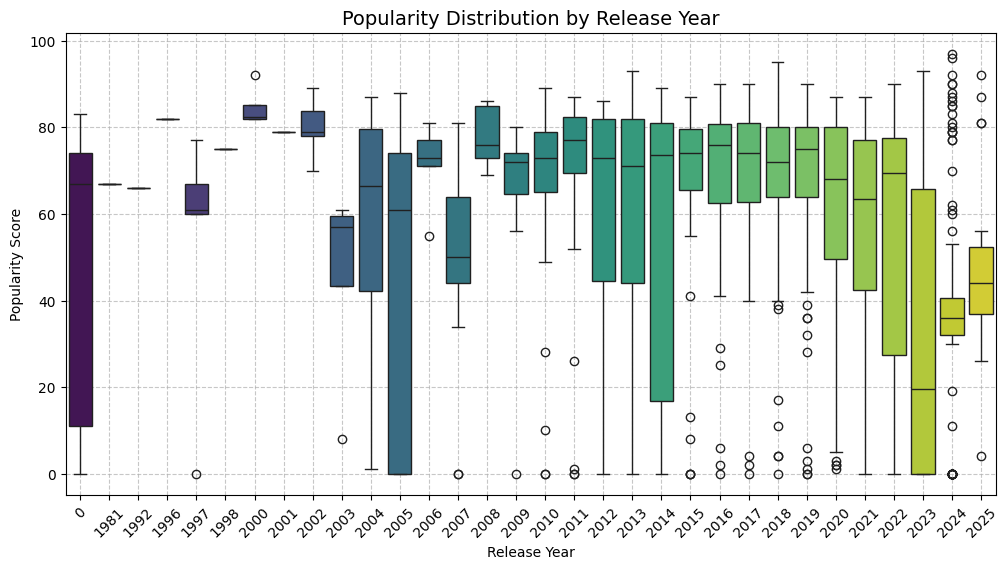

C:\Users\daphn\AppData\Local\Temp\ipykernel_9808\3208766454.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='magma')


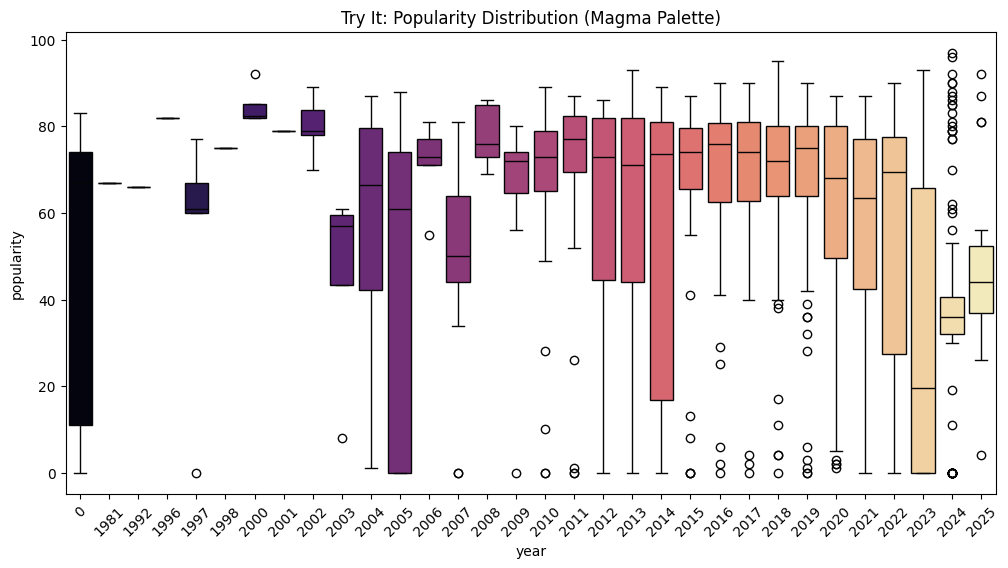

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='viridis')
plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Try It: Modify the palette parameter (e.g., to 'plasma' or 'magma'
plt.figure(figsize=(12, 6))

sns.boxplot(x='year', y='popularity', data=df, palette='magma')
plt.title('Try It: Popularity Distribution (Magma Palette)')
plt.xticks(rotation=45)
plt.show()

3. Scatter Plot

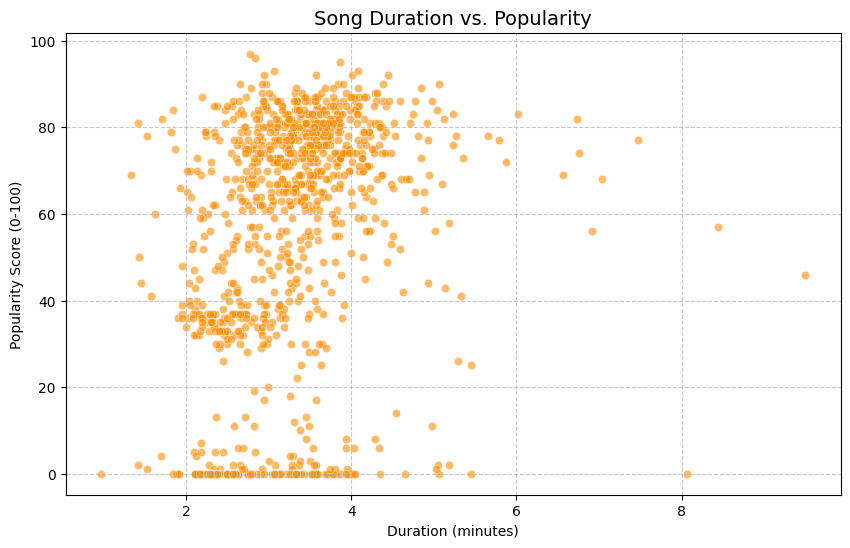

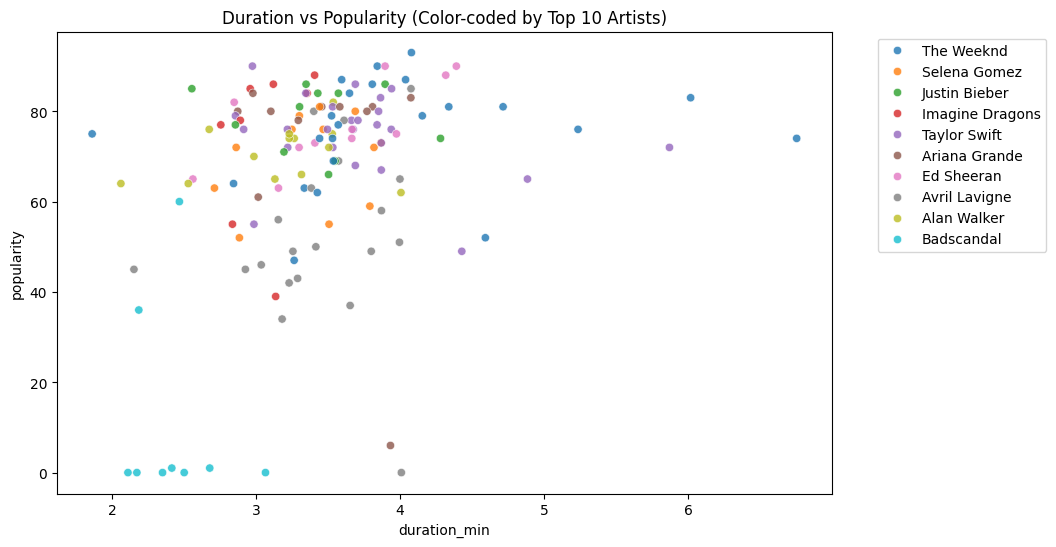

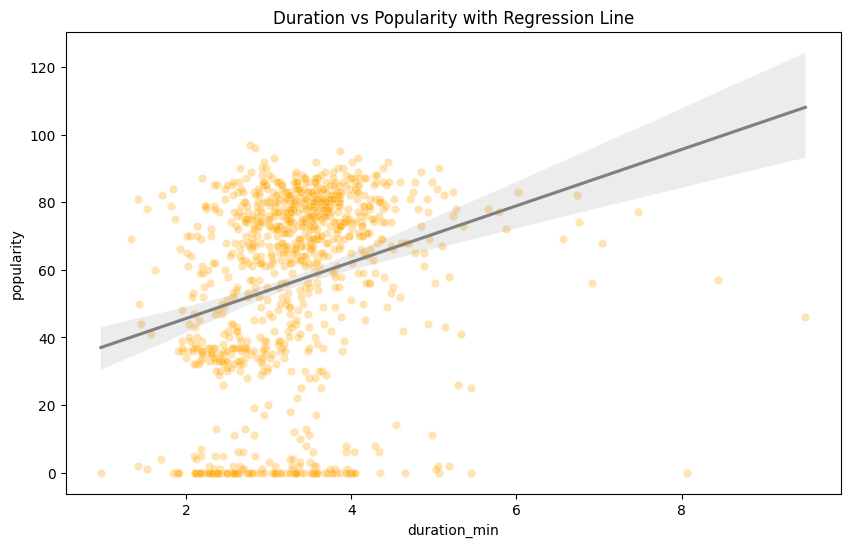

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.6,
color='darkorange')
plt.title('Song Duration vs. Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Try It: 
top_10_artists = df['artist'].value_counts().nlargest(10).index
filtered_df = df[df['artist'].isin(top_10_artists)]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', hue='artist', data=filtered_df, alpha=0.8)
plt.title('Duration vs Popularity (Color-coded by Top 10 Artists)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.3, color='orange')

sns.regplot(x='duration_min', y='popularity', data=df, scatter=False, color='grey')
plt.title('Duration vs Popularity with Regression Line')
plt.show()

4. Pair Plot

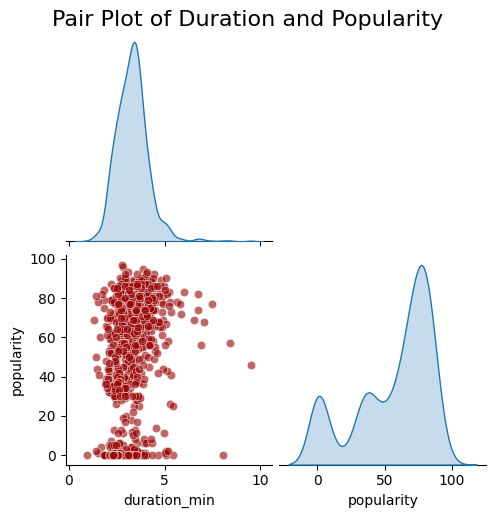


--- Running 'Try It' Variation ---


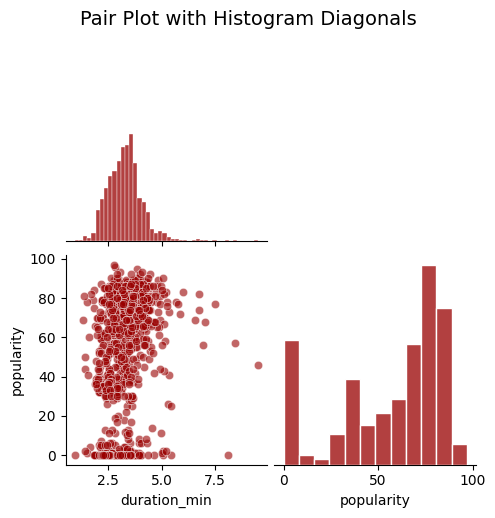

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using only the confirmed numerical columns: 'duration_min' and 'popularity'
key_features = ['duration_min', 'popularity']

# We use the simplified sns.pairplot function
sns.pairplot(
df[key_features],
diag_kind='kde',
corner=True,
plot_kws={'alpha': 0.6, 'color': '#990000'}
)
plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize=16)
plt.show()

# Try It: Change diag_kind='kde' to diag_kind='hist' to replace the smooth density curve
print("\n--- Running 'Try It' Variation ---")
sns.pairplot(
    df[key_features], 
    diag_kind='hist', 
    corner=True, 
    plot_kws={'alpha': 0.6, 'color': '#990000'},
    diag_kws={'color': '#990000', 'edgecolor': 'white'}
)
plt.suptitle('Pair Plot with Histogram Diagonals', y=1.02, fontsize=14)
plt.show()

5. Joint Plot

<Figure size 800x800 with 0 Axes>

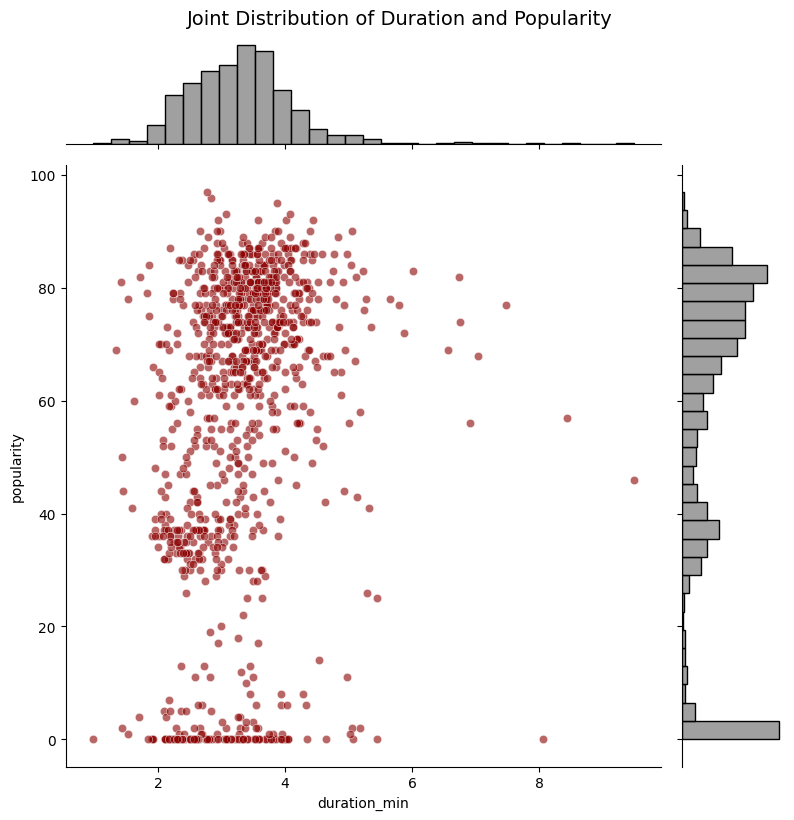

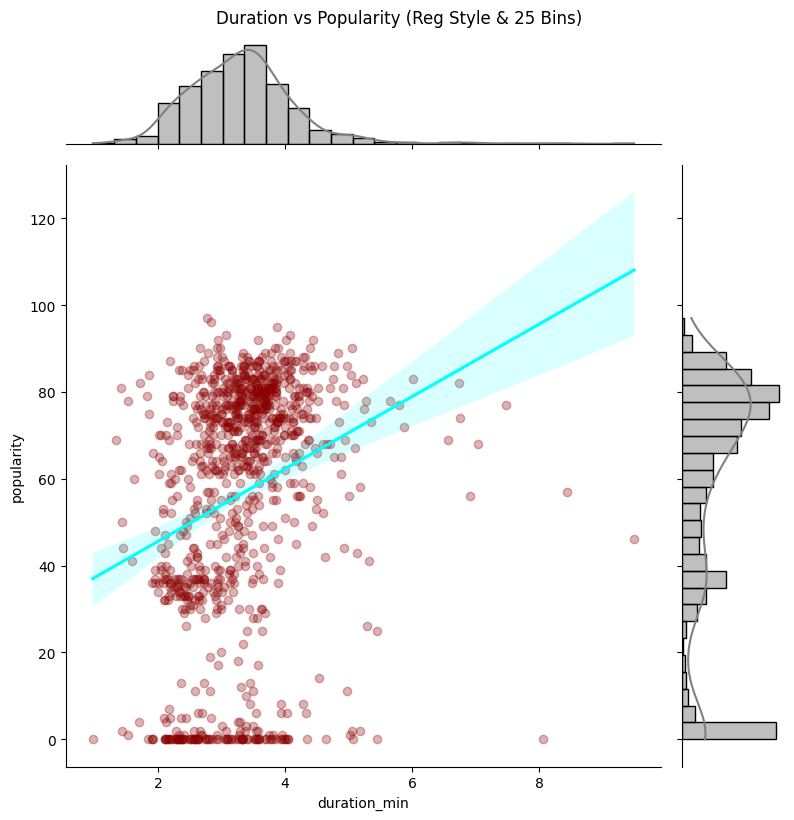

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='scatter', # Use 'scatter' for the central plot type
    height=8, # Controls the overall size of the plot
    marginal_kws={'bins': 30, 'color': 'gray', 'edgecolor': 'black'},
    joint_kws={'alpha': 0.6, 'color': 'darkred'}
)
plt.suptitle('Joint Distribution of Duration and Popularity', y=1.02,
fontsize=14)
plt.show()

# Try It: 
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='reg', 
    height=8,
    marginal_kws=dict(bins=25, color='gray', edgecolor='black'), # Try It: bins=25
    joint_kws={
        'line_kws': {'color': 'cyan'}, 
        'scatter_kws': {'alpha': 0.3, 'color': 'darkred'}
    }
)
plt.suptitle('Duration vs Popularity (Reg Style & 25 Bins)', y=1.02)
plt.show()

6. Animated Line Chart

In [3]:
# Requirements:
# pip install matplotlib pillow pandas
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser

# --- Step 1: Load Dataset ---
csv_files ="./spotify_top_1000_tracks.csv"
df = pd.read_csv(csv_files)

# --- Step 2: Data Preparation ---
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df = df.dropna(subset=['year'])

# Compute average popularity per year
yearly_popularity = df.groupby('year')['popularity'].mean().reset_index()
yearly_popularity = yearly_popularity.sort_values('year')

# --- Step 3: Initialize the Figure ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)
line, = ax.plot([], [], color='royalblue', linewidth=2.5, label='Average Popularity')

ax.set_title("Evolution of Track Popularity Over Time", fontsize=14, color='navy')
ax.set_xlabel("Year of Release", fontsize=12)
ax.set_ylabel("Average Popularity", fontsize=12)
ax.legend(loc="upper left")
plt.tight_layout()

# --- Step 4: Define Animation Function ---
def animate(i):
    x = yearly_popularity['year'][:i]
    y = yearly_popularity['popularity'][:i]
    line.set_data(x, y)
    return line,

# --- Step 5: Create and Save Animation ---
ani = FuncAnimation(fig, animate, frames=len(yearly_popularity), interval=100,
repeat=False)

# Automatically Save the GIF
gif_path = os.path.abspath("yearly_popularity_trend.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))
print(f" GIF saved successfully at: {gif_path}")

# --- Step 6: Open the Saved GIF ---
webbrowser.open(f"file://{gif_path}") # Opens the saved GIF automatically
plt.close(fig)

# Try It: Change Animation Speed
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax2.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)

line2, = ax2.plot([], [], color='crimson', linewidth=2.5, label='Average Popularity')
ax2.set_title("Try It: Track Popularity Over Time (Fast Speed)", fontsize=14)
ax2.legend()


ani_try = FuncAnimation(fig2, animate, frames=len(yearly_popularity), interval=60, repeat=False)

try_gif_path = os.path.abspath("try_it_yearly_popularity.gif")
ani_try.save(try_gif_path, writer=PillowWriter(fps=15))
print(f"Try It GIF saved at: {try_gif_path}")
plt.close(fig2)

 GIF saved successfully at: c:\Users\daphn\Lab7_Data_Visualization\yearly_popularity_trend.gif
Try It GIF saved at: c:\Users\daphn\Lab7_Data_Visualization\try_it_yearly_popularity.gif
